# Customer Churn Dataset

Dataset de Analítica de Interacción del Cliente y Abandono (Churn)
Un conjunto de 50.000 registros de clientes con 25 atributos que abarcan datos demográficos, patrones de comportamiento, historial de compras y métricas de interacción.

El conjunto de datos recoge interacciones multicanal de clientes a través de plataformas web, móviles, correo electrónico y redes sociales, proporcionando una visión 360° del comportamiento del cliente.
Incluye una variable objetivo binaria (Churned).

- Registros: 50.000
- Atributos: 25
- Variable a clasificar: Binaria (Cliente abandono [1] o no abandono[0])


##### Importacion de datos

In [3]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
pd.set_option('display.max_columns', None) #Para que se vean todas las columnas
churn_data = pd.read_csv("customer_churn.csv")
churn_data.head()

,Age,Gender,Country,City,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Discount_Usage_Rate,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned,Signup_Quarter
0,43.0,Male,France,Marseille,2.9,14.0,27.4,6.0,50.6,3.0,9.0,94.72,34.0,46.40,2.0,17.9,9.0,4.0,16.3,20.8,1.0,953.33,2278.0,0,Q1
1,36.0,Male,UK,Manchester,1.6,15.0,42.7,10.3,37.7,1.0,19.5,82.45,71.0,57.96,9.2,42.8,7.0,3.0,NaN,23.3,3.0,1067.47,3028.0,0,Q4
2,45.0,Female,Canada,Vancouver,2.9,10.0,24.8,1.6,70.9,1.0,9.1,165.52,11.0,12.24,11.5,0.0,4.0,1.0,NaN,8.8,NaN,1289.75,2317.0,0,Q4
3,56.0,Female,USA,New York,2.6,10.0,38.4,14.8,41.7,9.0,15.0,147.33,47.0,44.10,5.4,41.4,2.0,5.0,85.9,31.0,3.0,2340.92,2674.0,0,Q1
4,35.0,Male,India,Delhi,3.1,29.0,51.4,NaN,19.1,9.0,32.5,141.30,73.0,25.20,5.5,37.9,1.0,11.0,83.0,50.4,4.0,3041.29,5354.0,0,Q4


Revision de Tipos, Faltantes y Columnas

In [5]:
#Tipos de dato de cada variable y cantidad de no-nulos por cada una
churn_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            47505 non-null  float64
 1   Gender                         50000 non-null  object 
 2   Country                        50000 non-null  object 
 3   City                           50000 non-null  object 
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  float64
 6   Session_Duration_Avg           46601 non-null  float64
 7   Pages_Per_Session              47000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 46000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value            50000 non-null  float64
 12  Days_Since_Last_Purchase       47000 non-null 

Descriptivos por atributo

In [6]:
# Para las numericas
churn_data.select_dtypes(include='number').agg(['count', 'mean', 'std', 'min', 'max','median']) 

,Age,Membership_Years,Login_Frequency,Session_Duration_Avg,Pages_Per_Session,Cart_Abandonment_Rate,Wishlist_Items,Total_Purchases,Average_Order_Value,Days_Since_Last_Purchase,Discount_Usage_Rate,Returns_Rate,Email_Open_Rate,Customer_Service_Calls,Product_Reviews_Written,Social_Media_Engagement_Score,Mobile_App_Usage,Payment_Method_Diversity,Lifetime_Value,Credit_Balance,Churned
count,47505.000000,50000.000000,50000.000000,46601.000000,47000.000000,50000.000000,46000.000000,50000.000000,50000.000000,47000.000000,46500.000000,45509.000000,47472.000000,49832.000000,46500.000000,44000.000000,45000.000000,47500.000000,50000.000000,44500.000000,50000.000000
mean,37.802968,2.984009,11.624660,27.660754,8.737811,57.079973,4.298391,13.111576,123.117330,29.792872,41.997485,6.680913,20.937980,5.681831,2.853312,29.364466,19.371607,2.353874,1440.626292,1966.233258,0.289000
std,11.834668,2.059105,7.810657,10.871013,3.778220,16.282723,3.189754,7.017312,175.569714,29.695062,21.373642,6.143027,14.252561,2.676052,2.328948,20.574021,9.419252,1.110012,907.249443,1225.072166,0.453302
min,5.000000,0.100000,0.000000,1.000000,1.000000,0.000000,0.000000,-13.000000,26.380000,0.000000,0.240000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
max,200.000000,10.000000,46.000000,75.600000,24.100000,143.743350,28.000000,128.700000,9666.379178,287.000000,116.640000,99.615734,91.700000,21.000000,21.000000,100.000000,61.900000,5.000000,8987.240000,7197.000000,1.000000
median,38.000000,2.500000,11.000000,26.800000,8.400000,58.100000,4.000000,12.000000,112.970000,21.000000,40.200000,5.400000,19.700000,5.000000,2.000000,27.600000,18.600000,2.000000,1243.415000,1896.000000,0.000000


Cosas "raras" de los datos:
- Edad minima 5 y maxima 200
- Total_purchases minimo -13?
- 

In [7]:
# hay 30 menores de 18 y 20 mayores de 149, voy a limpiarlos, ya que alguien de 150 es imposible y de 10 años o menos es muy extraño
churn_data.groupby('Age').size()

Age
5.0        16
10.0       14
18.0     2639
19.0      493
20.0      550
         ... 
73.0       27
74.0       11
75.0       45
150.0       9
200.0      11
Length: 62, dtype: int64

In [8]:
# Voy a eliminar los que tienen compras totales negativas (no tiene sentido)
churn_data.groupby('Total_Purchases').size()


Total_Purchases
-13.0     1
-11.7     2
-10.4     1
-10.0     3
-9.1      1
         ..
 118.3    2
 123.5    2
 124.8    1
 127.4    1
 128.7    1
Length: 150, dtype: int64

In [9]:
# Solo conservar edades válidas y cantidades de compra validas
churn_data = churn_data.query("Age >= 18 and Age <= 100 and Total_Purchases >= 0")
print("Filas tras filtrar por edad y compras:", churn_data.shape[0])


Filas tras filtrar por edad y compras: 47418


In [10]:
# Para las categoricas
churn_data.select_dtypes(include='object').describe()

,Gender,Country,City,Signup_Quarter
count,47418,47418,47418,47418
unique,3,8,40,4
top,Female,USA,Houston,Q2
freq,23830,16468,3363,11907


# Algunos Graficos

### Histogramas para categoricas

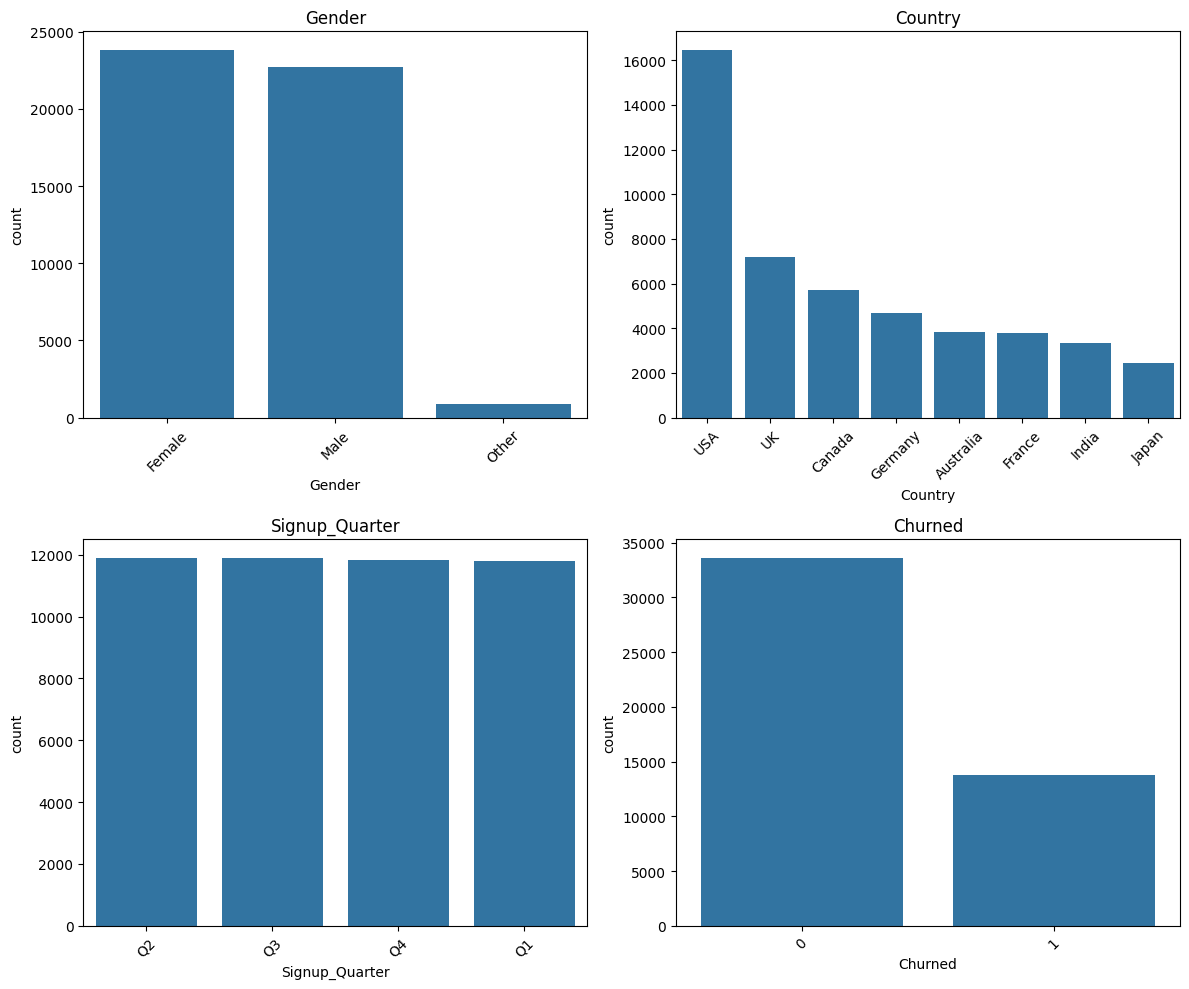

In [11]:

columns_to_plot = ['Gender', 'Country', 'Signup_Quarter','Churned']  

n_cols = 2  # columnas por fila
n_rows = (len(columns_to_plot) + n_cols - 1) // n_cols  # filas necesarias

plt.figure(figsize=(n_cols*6, n_rows*5))

for i, col in enumerate(columns_to_plot):
    plt.subplot(n_rows, n_cols, i+1)
    sns.countplot(data=churn_data, x=col, order=churn_data[col].value_counts().index)
    plt.xticks(rotation=45)
    plt.title(col)

plt.tight_layout()
plt.show()

Se observa desbalanceo entre clases, mayor cantidad de Churned

### Cuantitativas

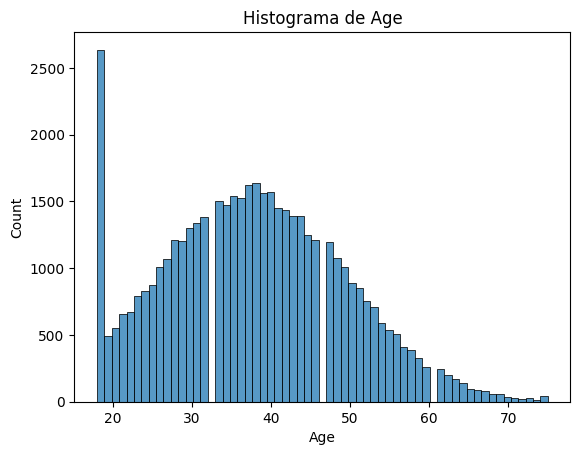

In [12]:
sns.histplot(data=churn_data, x=churn_data.Age)  
plt.title("Histograma de Age")
plt.show()
# Se observan muchas personas de 18 año, con esa salvedad la curva responde a distribucion normal.

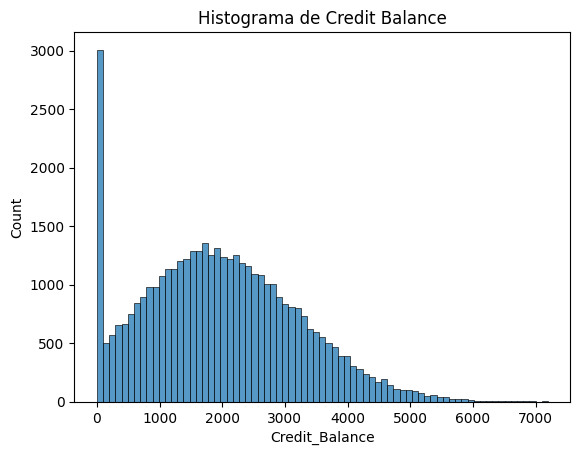

In [13]:
sns.histplot(data=churn_data, x=churn_data.Credit_Balance)  
plt.title("Histograma de Credit Balance")
plt.show()

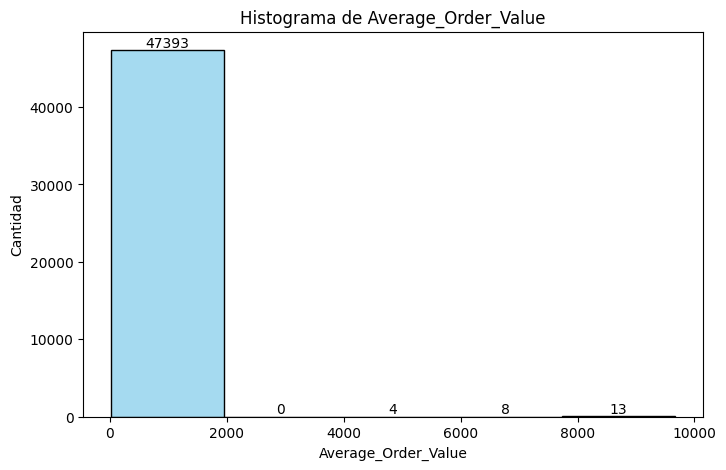

In [14]:
min_val = churn_data.Average_Order_Value.min()
max_val = churn_data.Average_Order_Value.max()

# 5 bins exactos
bins = np.linspace(min_val, max_val, 6)  # 6 puntos → 5 intervalos

# Crear histograma
plt.figure(figsize=(8,5))
ax = sns.histplot(churn_data['Average_Order_Value'], bins=bins, kde=False, stat='count', color='skyblue')

# Agregar cantidad encima de cada barra
for p in ax.patches:
    ax.annotate(
        int(p.get_height()), 
        (p.get_x() + p.get_width()/2., p.get_height()), 
        ha='center', 
        va='bottom'
    )

plt.title("Histograma de Average_Order_Value")
plt.xlabel("Average_Order_Value")
plt.ylabel("Cantidad")
plt.show()


Practicamente todos estan por debajo de los 2000 de promedio de compra, pero de aca no voy a borrar nada ya que esos compradores de grandes numeros pueden ser informacion real y util

# Preparacion de datos previo a entrenamiento

In [15]:
# Ver porcentaje de valores faltantes por columna
churn_data.isnull().mean() * 100


Age                               0.000000
Gender                            0.000000
Country                           0.000000
City                              0.000000
Membership_Years                  0.000000
Login_Frequency                   0.000000
Session_Duration_Avg              6.775908
Pages_Per_Session                 5.985069
Cart_Abandonment_Rate             0.000000
Wishlist_Items                    7.975874
Total_Purchases                   0.000000
Average_Order_Value               0.000000
Days_Since_Last_Purchase          6.031465
Discount_Usage_Rate               7.045848
Returns_Rate                      8.975495
Email_Open_Rate                   5.069805
Customer_Service_Calls            0.335316
Product_Reviews_Written           7.014214
Social_Media_Engagement_Score    12.008098
Mobile_App_Usage                  9.996204
Payment_Method_Diversity          5.019191
Lifetime_Value                    0.000000
Credit_Balance                   10.997933
Churned    

In [16]:
# Para las numericas voy a imputar con la mediana, ya que es mas robusta a outliers

num_cols = churn_data.select_dtypes(include='number').columns

for col in num_cols:
    median_value = churn_data[col].median()
    churn_data[col].fillna(median_value)

# Las categoricas les voy a poner una categoria extra

cat_cols = churn_data.select_dtypes(include='object').columns

for col in cat_cols:
    churn_data[col].fillna("Unknown")

churn_data.isnull().mean() * 100 # ya no hay mas faltantes


Age                               0.000000
Gender                            0.000000
Country                           0.000000
City                              0.000000
Membership_Years                  0.000000
Login_Frequency                   0.000000
Session_Duration_Avg              6.775908
Pages_Per_Session                 5.985069
Cart_Abandonment_Rate             0.000000
Wishlist_Items                    7.975874
Total_Purchases                   0.000000
Average_Order_Value               0.000000
Days_Since_Last_Purchase          6.031465
Discount_Usage_Rate               7.045848
Returns_Rate                      8.975495
Email_Open_Rate                   5.069805
Customer_Service_Calls            0.335316
Product_Reviews_Written           7.014214
Social_Media_Engagement_Score    12.008098
Mobile_App_Usage                  9.996204
Payment_Method_Diversity          5.019191
Lifetime_Value                    0.000000
Credit_Balance                   10.997933
Churned    

separo variables de la target

In [17]:
y = churn_data['Churned']  # 1 si el cliente abandonó, 0 si no
X = churn_data.drop(columns=['Churned'])


Identificar categóricas y numéricas

Codificar categóricas (One-Hot o Label)

In [18]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import FunctionTransformer

In [19]:
cat_cols = X.select_dtypes(include='object').columns.tolist()  # categóricas
num_cols = X.select_dtypes(include='number').columns.tolist()  # numéricas

# Preprocesador: solo OneHot para categóricas, numéricas tal cual
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first', sparse_output=False), cat_cols)
    ],
    remainder='passthrough'
)

# Aplicar transformación
X_processed_array = preprocessor.fit_transform(X)

# Crear nombres de columnas
columns = list(preprocessor.get_feature_names_out())
# Renombrar numéricas para quitar 'remainder__'
columns = [col.replace('remainder__','') for col in columns]

# Convertir a DataFrame
X_processed = pd.DataFrame(X_processed_array, columns=columns, index=X.index)

print("Columnas procesadas:", X_processed.shape[1])

Columnas procesadas: 71


Dividir train-test

In [20]:
from sklearn.model_selection import train_test_split

In [21]:
# Divido 80% entrenamiento / 20% prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, 
    y, 
    test_size=0.2,         # 20% de los datos para test
    random_state=42,        # semilla para reproducibilidad
    stratify=y              # mantiene la proporción de clases
)

Armado del modelo

RandomForest

In [22]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

In [23]:
seeds = range(15)  # mínimo 15 seeds
train_acc_list = []
test_acc_list = []
importances_list = []

for seed in seeds:
    # Crear modelo con seed diferente
    rf_clf = RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        random_state=seed,
        class_weight='balanced'
    )
    
    # Entrenar
    rf_clf.fit(X_train, y_train)
    
    # Predicciones
    y_train_pred = rf_clf.predict(X_train)
    y_test_pred = rf_clf.predict(X_test)
    
    # Guardar métricas
    train_acc_list.append(accuracy_score(y_train, y_train_pred))
    test_acc_list.append(accuracy_score(y_test, y_test_pred))
    
    # Guardar importancias de features
    importances_list.append(rf_clf.feature_importances_)

Tiempo de entrenamiento para todos los seed -> 2m 39.5s

Especificaciones dispositivo:
- Device name	LAPTOP-FDE8NOVO
- Processor	12th Gen Intel(R) Core(TM) i7-12700H (2.30 GHz)
- Installed RAM	16.0 GB (15.7 GB usable)
- System type	64-bit operating system, x64-based processor

In [24]:
# Convertir a arrays numpy para cálculos
train_acc_arr = np.array(train_acc_list)
test_acc_arr = np.array(test_acc_list)
importances_arr = np.array(importances_list)  # shape = (15, n_features)

# Promedio y desviación de métricas
print(f"Train Accuracy: {train_acc_arr.mean():.4f} ± {train_acc_arr.std():.4f}")
print(f"Test Accuracy: {test_acc_arr.mean():.4f} ± {test_acc_arr.std():.4f}")

# Promedio y desviación de importancias de features
mean_importances = importances_arr.mean(axis=0)
std_importances = importances_arr.std(axis=0)

# Mostrar top features con media y desviación
indices = np.argsort(mean_importances)[::-1]
print("\nFeature Importances promedio ± desviación:")
for i in indices[:20]:  # Top 20
    print(f"{columns[i]}: {mean_importances[i]:.4f} ± {std_importances[i]:.4f}")

Train Accuracy: 0.9241 ± 0.0006
Test Accuracy: 0.8962 ± 0.0010

Feature Importances promedio ± desviación:
Customer_Service_Calls: 0.1652 ± 0.0047
Lifetime_Value: 0.1349 ± 0.0047
Cart_Abandonment_Rate: 0.1100 ± 0.0030
Age: 0.0734 ± 0.0019
Total_Purchases: 0.0542 ± 0.0028
Email_Open_Rate: 0.0528 ± 0.0019
Discount_Usage_Rate: 0.0493 ± 0.0023
Session_Duration_Avg: 0.0488 ± 0.0031
Average_Order_Value: 0.0472 ± 0.0030
Days_Since_Last_Purchase: 0.0465 ± 0.0010
Pages_Per_Session: 0.0364 ± 0.0026
Mobile_App_Usage: 0.0326 ± 0.0019
Wishlist_Items: 0.0273 ± 0.0022
Login_Frequency: 0.0224 ± 0.0017
Product_Reviews_Written: 0.0196 ± 0.0018
Social_Media_Engagement_Score: 0.0180 ± 0.0009
Returns_Rate: 0.0155 ± 0.0003
Credit_Balance: 0.0133 ± 0.0007
Membership_Years: 0.0069 ± 0.0001
Payment_Method_Diversity: 0.0035 ± 0.0001


In [25]:
from sklearn.metrics import classification_report, confusion_matrix


In [26]:

y_pred = rf_clf.predict(X_test)
print(classification_report(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.94      0.92      0.93      6726
           1       0.81      0.85      0.83      2758

    accuracy                           0.90      9484
   macro avg       0.87      0.88      0.88      9484
weighted avg       0.90      0.90      0.90      9484

[[6176  550]
 [ 422 2336]]


Importancia de cada feature

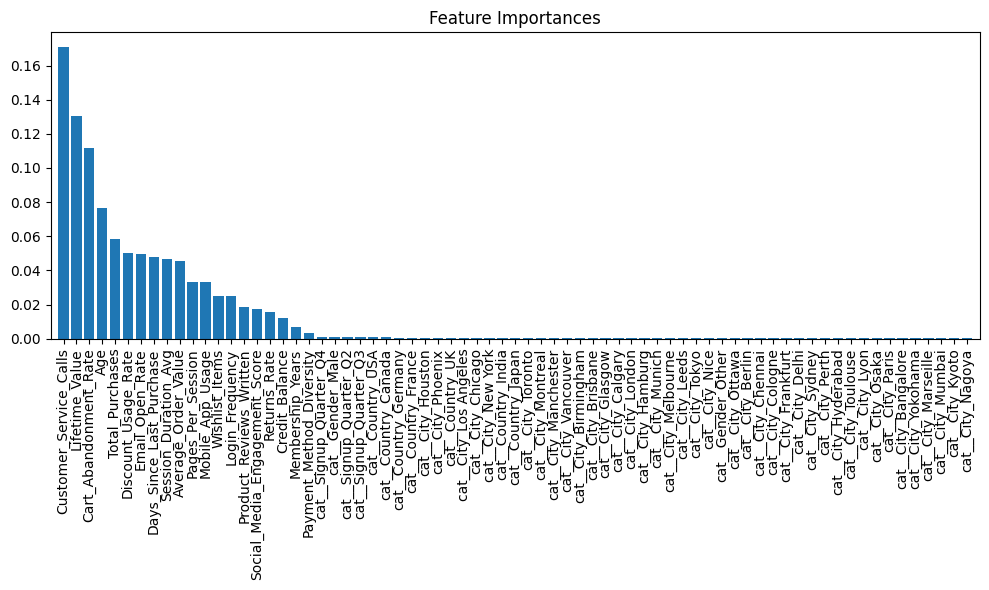

In [27]:
importances = rf_clf.feature_importances_
indices = np.argsort(importances)[::-1]

feature_names = X_train.columns.to_numpy()

plt.figure(figsize=(10, 6))
plt.title("Feature Importances")
plt.bar(range(X_train.shape[1]), importances[indices], align="center")
plt.xticks(
    range(X_train.shape[1]),
    feature_names[indices],
    rotation=90
)
plt.xlim([-1, X_train.shape[1]])
plt.tight_layout()
plt.show()


Regresion Lineal

In [30]:
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


In [31]:
logit_clf = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # ← clave
    ('scaler', StandardScaler()),
    ('logit', LogisticRegression(
        max_iter=1000,
        class_weight='balanced',
        random_state=42
    ))
])

# Entrenar
logit_clf.fit(X_train, y_train)

# Predicciones
y_train_pred_logit = logit_clf.predict(X_train)
y_test_pred_logit = logit_clf.predict(X_test)

# Métricas
print("LOGISTIC REGRESSION")
print(f"Train Accuracy: {accuracy_score(y_train, y_train_pred_logit):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred_logit):.4f}")

print(classification_report(y_test, y_test_pred_logit))


LOGISTIC REGRESSION
Train Accuracy: 0.7159
Test Accuracy: 0.7112
              precision    recall  f1-score   support

           0       0.86      0.70      0.78      6726
           1       0.50      0.73      0.59      2758

    accuracy                           0.71      9484
   macro avg       0.68      0.72      0.69      9484
weighted avg       0.76      0.71      0.72      9484



In [32]:
coef = logit_clf.named_steps['logit'].coef_[0]

coef_df = pd.DataFrame({
    'feature': X_train.columns,
    'coef': coef
}).sort_values(by='coef', ascending=False)

print(coef_df.head(15))
print(coef_df.tail(15))


                     feature      coef
69            Lifetime_Value  0.785248
64    Customer_Service_Calls  0.580759
56     Cart_Abandonment_Rate  0.539284
60  Days_Since_Last_Purchase  0.377309
62              Returns_Rate  0.191445
30       cat__City_Melbourne  0.044745
8           cat__Country_USA  0.040356
50    cat__Signup_Quarter_Q4  0.033007
2        cat__Country_Canada  0.031819
40           cat__City_Perth  0.031081
70            Credit_Balance  0.028569
4       cat__Country_Germany  0.027100
29       cat__City_Marseille  0.026856
16         cat__City_Cologne  0.026434
44         cat__City_Toronto  0.026350
                    feature      coef
14        cat__City_Chennai -0.011754
53          Login_Frequency -0.011879
36           cat__City_Nice -0.014039
18      cat__City_Frankfurt -0.014756
0          cat__Gender_Male -0.014827
43          cat__City_Tokyo -0.023018
49   cat__Signup_Quarter_Q3 -0.033968
57           Wishlist_Items -0.044929
67         Mobile_App_Usage -0.045

Naive Bayes

In [35]:
from sklearn.naive_bayes import GaussianNB
from sklearn.impute import SimpleImputer # uso imputacion
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report


In [36]:
nb_clf = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),  # ← obligatorio
    ('nb', GaussianNB())
])

# Entrenar
nb_clf.fit(X_train, y_train)

# Predicciones
y_train_pred_nb = nb_clf.predict(X_train)
y_test_pred_nb = nb_clf.predict(X_test)

# Métricas
print("NAIVE BAYES")
print(f"Train Accuracy: {accuracy_score(y_train, y_train_pred_nb):.4f}")
print(f"Test Accuracy: {accuracy_score(y_test, y_test_pred_nb):.4f}")

print(classification_report(y_test, y_test_pred_nb))


NAIVE BAYES
Train Accuracy: 0.6586
Test Accuracy: 0.6490
              precision    recall  f1-score   support

           0       0.80      0.67      0.73      6726
           1       0.43      0.60      0.50      2758

    accuracy                           0.65      9484
   macro avg       0.62      0.64      0.61      9484
weighted avg       0.69      0.65      0.66      9484



In [37]:
results = pd.DataFrame({
    'Modelo': ['Random Forest', 'Logistic Regression', 'Naive Bayes'],
    'Train Accuracy': [
        train_acc_arr.mean(),
        accuracy_score(y_train, y_train_pred_logit),
        accuracy_score(y_train, y_train_pred_nb)
    ],
    'Test Accuracy': [
        test_acc_arr.mean(),
        accuracy_score(y_test, y_test_pred_logit),
        accuracy_score(y_test, y_test_pred_nb)
    ]
})

print(results)


                Modelo  Train Accuracy  Test Accuracy
0        Random Forest        0.924066       0.896190
1  Logistic Regression        0.715928       0.711198
2          Naive Bayes        0.658591       0.648988


La reducción promedio de impureza (Gini para clasificación, MSE para regresión) que aporta cada feature al dividir los nodos, ponderada por la cantidad de muestras que pasan por el nodo y sumada a lo largo de todos los árboles del bosque.
- Cada número es relativo a los demás.
- Si una feature tiene 0.32 y otra 0.21:
- La primera contribuye un 32 % de la capacidad predictiva, la segunda un 21 %.
- La suma de todas las importancias es exactamente 1, porque es una distribución de “peso” total de importancia entre todas las variables.

Interpretaciones cualitativas importantes:

Customer_Service_Calls	0.165:
- La cantidad de llamadas al servicio al cliente es la variable más relevante para predecir churn. Si un cliente llama más,el modelo lo considera con más riesgo de abandono.

Lifetime_Value	0.135:
- Valor total esperado del cliente; los clientes de mayor o menor valor influyen mucho en la predicción.

Cart_Abandonment_Rate	0.110:
- Clientes que abandonan el carrito con frecuencia tienen mayor probabilidad de churn según el modelo.

El Random Forest identifica como más relevantes las variables Customer_Service_Calls, Lifetime_Value y Cart_Abandonment_Rate, contribuyendo aproximadamente al 16 %, 13 % y 11 % de la capacidad predictiva del modelo, respectivamente. Variables como Membership_Years y Payment_Method_Diversity tienen muy poca importancia global (<1 %), indicando que influyen poco en la predicción de churn. La baja desviación típica de las importancias (0.001–0.005) muestra que el ranking de variables es estable frente a la naturaleza estocástica del modelo